# bellwether-agent evaluation

Every number here is computed from the trial records in `eval/results/`.
Nothing is entered by hand.

The agent is non-deterministic, so each scenario is run several times and
results are reported as rates rather than single outcomes. Trials where
the language model provider refused service are recorded but excluded
from the rates, because they measure the provider rather than the agent.

In [1]:
import json
import collections
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS = Path("results")


def load_arm(label: str) -> pd.DataFrame:
    """Load one evaluation arm, keeping the last record per trial.

    A trial re-run after a provider failure appends a new record; the
    original stays in the file as evidence and is superseded here.
    """
    path = RESULTS / f"{label}.jsonl"
    if not path.exists():
        return pd.DataFrame()
    rows = [json.loads(line) for line in path.open(encoding="utf-8")]
    latest = {(r["scenario_id"], r["trial"]): r for r in rows}
    df = pd.DataFrame(latest.values())
    df["step_limit"] = df["config_snapshot"].apply(
        lambda c: c["max_steps_per_investigation"])
    df["hit_step_limit"] = df["stop_reason"].str.contains("step limit")
    df["agent_ran"] = df.get("agent_ran", True)
    return df


baseline = load_arm("baseline")
steps12 = load_arm("steps12")

for name, df in [("baseline", baseline), ("steps12", steps12)]:
    if df.empty:
        print(f"{name}: not run yet")
    else:
        valid = df[df["agent_ran"]]
        print(f"{name}: {len(df)} trials, {len(valid)} valid, "
              f"step limit {valid['step_limit'].iloc[0]}")

baseline: 10 trials, 10 valid, step limit 8
steps12: 4 trials, 4 valid, step limit 12


## Task completion rate

A trial passes only if the memo mentions every concept the scenario
requires, avoids conclusions the ground truth rules out, and has every
figure traceable to a tool result gathered during that investigation.
Scenarios whose correct answer is "the cause could not be established"
additionally require the agent to have finished on its own judgement,
so that honest uncertainty is not confused with running out of steps.

In [2]:
def rates(df: pd.DataFrame) -> pd.DataFrame:
    valid = df[df["agent_ran"]]
    out = (valid.groupby("scenario_id")
           .agg(trials=("passed", "size"),
                passed=("passed", "sum"),
                mean_steps=("steps_used", "mean"),
                hit_limit=("hit_step_limit", "sum"))
           .assign(rate=lambda d: d["passed"] / d["trials"]))
    return out.sort_values("rate", ascending=False)


valid = baseline[baseline["agent_ran"]]
overall = valid["passed"].sum() / len(valid)
print(f"Baseline completion rate: {valid['passed'].sum()}/{len(valid)} "
      f"({overall:.0%})")
print(f"Trials stopped by the step limit: {valid['hit_step_limit'].sum()}"
      f"/{len(valid)}")
rates(baseline)

Baseline completion rate: 5/10 (50%)
Trials stopped by the step limit: 8/10


,trials,passed,mean_steps,hit_limit,rate
scenario_id,,,,,
berkshire_chubb_accumulation,2,2,9.0,2,1.0
cmg_split_trap,2,2,9.0,2,1.0
pershing_cp_rename,2,1,7.5,0,0.5
scion_concentration_q2_2024,2,0,9.0,2,0.0
scion_hcaexit_unexplained,2,0,9.0,2,0.0


## Failure taxonomy

The categories below are derived from the failure reasons the harness
recorded, not from a list of failures imagined in advance. Each category
prints a real example, identified by scenario and trial number, so any
entry can be traced back to the raw record in `eval/results/`.

In [3]:
def categorise(row) -> list[str]:
    """Map one trial's recorded reasons onto failure categories."""
    cats = []
    reasons = " ".join(row["reasons"]).lower()
    if "missing any of" in reasons:
        cats.append("conclusion missed a required concept")
    if "forbidden conclusion" in reasons:
        cats.append("reached a conclusion the evidence rules out")
    if "not fully traceable" in reasons:
        cats.append("memo contained figures not found in the evidence")
    if "does not demonstrate honest uncertainty" in reasons:
        cats.append("stopped by a guardrail before concluding")
    if not cats and not row["passed"]:
        cats.append("uncategorised")
    return cats


failures = baseline[baseline["agent_ran"] & ~baseline["passed"]].copy()
failures["categories"] = failures.apply(categorise, axis=1)

MARKERS = {
    "conclusion missed a required concept": "missing any of",
    "reached a conclusion the evidence rules out": "forbidden conclusion",
    "memo contained figures not found in the evidence": "not fully traceable",
    "stopped by a guardrail before concluding": "honest uncertainty",
}

counts = collections.Counter(
    c for cats in failures["categories"] for c in cats)
print(f"{len(failures)} failed trials produced "
      f"{sum(counts.values())} category assignments\n")
for cat, n in counts.most_common():
    example = next(r for _, r in failures.iterrows() if cat in r["categories"])
    marker = MARKERS.get(cat, "")
    detail = next((x for x in example["reasons"] if marker in x.lower()),
                  example["reasons"][0])
    print(f"{n:>2}x  {cat}")
    print(f"      example: {example['scenario_id']} trial {example['trial']}")
    print(f"      recorded reason: {detail[:110]}\n")

5 failed trials produced 8 category assignments

 3x  conclusion missed a required concept
      example: pershing_cp_rename trial 1
      recorded reason: missing any of: ['merger', 'rename', 'renamed', 'reorganisation', 'reorganization', 'kansas city southern', 's

 3x  memo contained figures not found in the evidence
      example: pershing_cp_rename trial 1
      recorded reason: memo figures not fully traceable to evidence

 2x  stopped by a guardrail before concluding
      example: scion_hcaexit_unexplained trial 1
      recorded reason: investigation did not complete, so an inconclusive memo does not demonstrate honest uncertainty



## Confidence calibration

The memo states a confidence level. If that statement is meaningful,
high-confidence memos should be correct more often than low-confidence
ones.

In [4]:
valid = baseline[baseline["agent_ran"]]
calib = (valid.groupby("stated_confidence")
         .agg(trials=("passed", "size"), correct=("passed", "sum"))
         .assign(accuracy=lambda d: d["correct"] / d["trials"]))
print(calib.to_string())
print("\nA confidence level is informative only if accuracy rises with it.")

                   trials  correct  accuracy
stated_confidence                           
high                    2        2  1.000000
low                     2        2  1.000000
medium                  6        1  0.166667

A confidence level is informative only if accuracy rises with it.


## Before and after: raising the step limit

In the baseline, eight of ten trials ended because the agent hit the
step ceiling rather than because it decided it had finished. That makes
the ceiling, not the agent's reasoning, the most likely constraint on
completion. The experiment raises `max_steps_per_investigation` from 8
to 12 and changes nothing else, so any difference in the completion rate
is attributable to that one variable.

In [5]:
def arm_summary(df: pd.DataFrame, label: str) -> dict:
    valid = df[df["agent_ran"]]
    return {
        "arm": label,
        "step_limit": int(valid["step_limit"].iloc[0]),
        "trials": len(valid),
        "passed": int(valid["passed"].sum()),
        "completion_rate": valid["passed"].mean(),
        "hit_step_limit": int(valid["hit_step_limit"].sum()),
        "mean_steps": valid["steps_used"].mean(),
        "mean_llm_calls": valid["llm_calls"].mean(),
        "mean_seconds": valid["elapsed_seconds"].mean(),
    }


arms = [arm_summary(df, name) for name, df in
        [("baseline", baseline), ("steps12", steps12)] if not df.empty]
comparison = pd.DataFrame(arms).set_index("arm")
print(comparison.to_string(float_format=lambda v: f"{v:.2f}"))

if len(arms) == 2:
    delta = arms[1]["completion_rate"] - arms[0]["completion_rate"]
    print(f"\nRaising the step limit from {arms[0]['step_limit']} to "
          f"{arms[1]['step_limit']} moved the completion rate from "
          f"{arms[0]['completion_rate']:.0%} to "
          f"{arms[1]['completion_rate']:.0%}, a change of {delta:+.0%}.")
    print(f"Trials stopped by the step limit went from "
          f"{arms[0]['hit_step_limit']}/{arms[0]['trials']} to "
          f"{arms[1]['hit_step_limit']}/{arms[1]['trials']}.")
else:
    print("\nThe steps12 arm has not been run yet.")

          step_limit  trials  passed  completion_rate  hit_step_limit  mean_steps  mean_llm_calls  mean_seconds
arm                                                                                                            
baseline           8      10       5             0.50               8        8.70           10.20        356.57
steps12           12       4       3             0.75               1       10.25           12.50        308.00

Raising the step limit from 8 to 12 moved the completion rate from 50% to 75%, a change of +25%.
Trials stopped by the step limit went from 8/10 to 1/4.


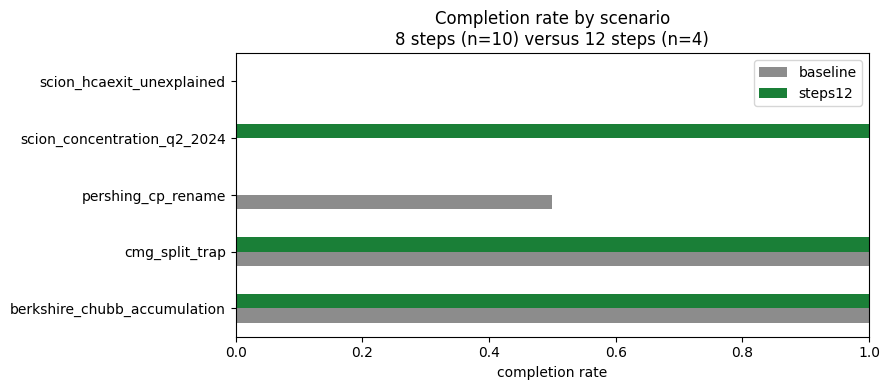

In [6]:
if len(arms) == 2:
    per_arm = {}
    for name, df in [("baseline", baseline), ("steps12", steps12)]:
        valid = df[df["agent_ran"]]
        per_arm[name] = valid.groupby("scenario_id")["passed"].mean()
    chart = pd.DataFrame(per_arm)

    plt.close("all")
    fig, ax = plt.subplots(figsize=(9, 4))
    chart.plot(kind="barh", ax=ax, color=["#8c8c8c", "#1a7f37"])
    ax.set_xlim(0, 1)
    ax.set_xlabel("completion rate")
    ax.set_ylabel("")
    n_base = len(baseline[baseline["agent_ran"]])
    n_exp = len(steps12[steps12["agent_ran"]])
    ax.set_title(f"Completion rate by scenario\n"
                 f"8 steps (n={n_base}) versus 12 steps (n={n_exp})")
    ax.legend(title="")
    plt.tight_layout()
    plt.show()
else:
    print("Chart will render once both arms are complete.")

In [7]:
summary_rows = []
for name, df in [("baseline", baseline), ("steps12", steps12)]:
    if df.empty:
        continue
    valid = df[df["agent_ran"]]
    for sid, g in valid.groupby("scenario_id"):
        summary_rows.append({
            "arm": name,
            "step_limit": int(g["step_limit"].iloc[0]),
            "scenario_id": sid,
            "trials": len(g),
            "passed": int(g["passed"].sum()),
            "completion_rate": round(g["passed"].mean(), 3),
            "mean_steps": round(g["steps_used"].mean(), 1),
            "hit_step_limit": int(g["hit_step_limit"].sum()),
        })

summary = pd.DataFrame(summary_rows)
summary.to_csv(RESULTS / "summary.csv", index=False)
print(f"Wrote {RESULTS / 'summary.csv'}")
summary

Wrote results\summary.csv


,arm,step_limit,scenario_id,trials,passed,completion_rate,mean_steps,hit_step_limit
0,baseline,8,berkshire_chubb_accumulation,2,2,1.0,9.0,2
1,baseline,8,cmg_split_trap,2,2,1.0,9.0,2
2,baseline,8,pershing_cp_rename,2,1,0.5,7.5,0
3,baseline,8,scion_concentration_q2_2024,2,0,0.0,9.0,2
4,baseline,8,scion_hcaexit_unexplained,2,0,0.0,9.0,2
5,steps12,12,berkshire_chubb_accumulation,1,1,1.0,13.0,1
6,steps12,12,cmg_split_trap,1,1,1.0,12.0,0
7,steps12,12,pershing_cp_rename,1,0,0.0,6.0,0
8,steps12,12,scion_concentration_q2_2024,1,1,1.0,10.0,0
